<img src="https://raw.githubusercontent.com/sambanova/.github/main/profile/sambanova_logo.png" width="260">

# Session 2 — Scaling the Executors
### Parallelism, Best-of-N, and the Economics

*Coding Agents That Improve* · Data Science Dojo × SambaNova · **Session 2 of 6**

---

In **Session 1** we split the coding agent in two: a frontier model **plans**, and a fast
SambaNova model **executes** the dozens of edits and test runs. That moved most of the tokens
to the executor.

This notebook is about what happens when the executor stops being *one* worker.

Almost everything written about coding agents assumes **one developer, one agent, one laptop**.
That is the easy case, and it hides every interesting problem. The moment you run **N candidates
for one task**, or **a team's worth of agents at once**, you are no longer running a CLI — you are
operating a multi-tenant, inference-bound system.

| | One agent on a laptop | Many agents, served |
|---|---|---|
| **Inference** | One stream, idle most of the time | Bursts of N concurrent streams |
| **Workspace** | Your working tree — you are the isolation | N agents cannot share a tree |
| **Failure** | You watch it, you Ctrl-C it | Nobody is watching |
| **Context** | One context bill | N context bills, concurrently |

**What we build here:**

1. **The latency budget** — measure where an agent's wall-clock actually goes.
2. **Concurrency** — fan out to N executors and show wall-clock is `max`, not `sum`.
3. **Best-of-N** — N candidate patches, and the **test suite** picks the winner. No judge, no vibes.
4. **The economics** — what N actually costs, using live prices from the API.

Everything here runs against **SambaNova Cloud** with a free-tier key, and every number in this
notebook is measured at run time on your own account — nothing is hard-coded.

## 0. Setup

You need a `SAMBANOVA_API_KEY` in a `.env` file (get one free at
[cloud.sambanova.ai](https://cloud.sambanova.ai/)).

In [1]:
# !pip install openai python-dotenv pandas matplotlib pytest -q

In [2]:
import asyncio
import os
import re
import subprocess
import sys
import tempfile
import time
from math import comb
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from openai import AsyncOpenAI, OpenAI

load_dotenv()

BASE_URL = "https://api.sambanova.ai/v1"
API_KEY = os.environ["SAMBANOVA_API_KEY"]

# The executor: fast, cheap, long-context. This is the model doing the dozens of edits.
EXECUTOR = "gpt-oss-120b"

client = OpenAI(base_url=BASE_URL, api_key=API_KEY)
aclient = AsyncOpenAI(base_url=BASE_URL, api_key=API_KEY)

print(f"Executor model: {EXECUTOR}")

Executor model: gpt-oss-120b


### The model registry — read it, don't hard-code it

A recurring theme in this series: **ask the provider what it serves** rather than baking
constants into your harness. Context windows and prices change; your compaction thresholds and
your cost model should follow them automatically.

In [3]:
models = client.models.list()

registry = pd.DataFrame(
    [
        {
            "model": m.id,
            "context": getattr(m, "context_length", None),
            "$/M in": round(float(getattr(m, "pricing", {}).get("prompt", 0)) * 1e6, 3),
            "$/M out": round(float(getattr(m, "pricing", {}).get("completion", 0)) * 1e6, 3),
        }
        for m in models.data
    ]
).sort_values("$/M out").reset_index(drop=True)

registry

,model,context,$/M in,$/M out
0,gpt-oss-120b,131072,0.22,0.59
1,gemma-4-31B-it,131072,0.38,1.15
2,Meta-Llama-3.3-70B-Instruct,131072,0.60,1.20
3,MiniMax-M2.7,196608,0.60,2.40
4,MiniMax-M3,1048576,0.60,2.40
5,DeepSeek-V3.1,131072,3.00,4.50
6,DeepSeek-V3.2,32768,3.00,4.50


In [4]:
# Pull the executor's real context window and price straight out of the registry.
row = registry[registry.model == EXECUTOR].iloc[0]
CTX_WINDOW = int(row["context"])
PRICE_IN = float(row["$/M in"]) / 1e6
PRICE_OUT = float(row["$/M out"]) / 1e6

# Harnesses should auto-compact BELOW the ceiling, not at it. ~80% is a sane default.
COMPACT_AT = int(CTX_WINDOW * 0.82)

print(f"{EXECUTOR}: context {CTX_WINDOW:,} tokens | ${PRICE_IN*1e6:.2f}/M in | ${PRICE_OUT*1e6:.2f}/M out")
print(f"Auto-compact threshold: {COMPACT_AT:,} tokens (82% of the window)")

gpt-oss-120b: context 131,072 tokens | $0.22/M in | $0.59/M out
Auto-compact threshold: 107,479 tokens (82% of the window)


---
## 1. Interactivity is an engineering spec

A coding agent is **not** a batch job. It is an interactive loop with a human waiting, and its
session time is, to a first approximation:

```
wall-clock  ≈  Σ over turns ( TTFT + output_tokens / throughput )  +  tool time
```

Two properties of coding agents make that sum brutal:

* they are **output-heavy** — they write code, they don't just answer; and
* they are **many-turned** — a non-trivial fix is routinely 30–60 model turns.

So per-user output speed, not model quality, decides whether a developer stays in the loop.
Let's measure it rather than assume it.

In [5]:
def measure_stream(prompt: str, model: str = EXECUTOR, temperature: float = 0.2) -> dict:
    """One streamed completion, instrumented: TTFT, output tokens, tok/s."""
    t0 = time.perf_counter()
    ttft, pieces, usage = None, [], None

    stream = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        stream=True,
        stream_options={"include_usage": True},
    )
    for chunk in stream:
        if chunk.usage:
            usage = chunk.usage
        if chunk.choices and chunk.choices[0].delta and chunk.choices[0].delta.content:
            if ttft is None:
                ttft = time.perf_counter() - t0
            pieces.append(chunk.choices[0].delta.content)

    total = time.perf_counter() - t0
    text = "".join(pieces)
    out_tokens = usage.completion_tokens if usage else len(pieces)
    generation_time = total - (ttft or 0)

    return {
        "ttft": ttft,
        "total": total,
        "out_tokens": out_tokens,
        "tok_per_s": out_tokens / generation_time if generation_time > 0 else 0.0,
        "text": text,
    }

### The task

We need a task that is *genuinely hard* — one where a single shot often fails. That is the whole
point of best-of-N later: if every attempt succeeds, N is a waste of money.

This one is a small expression evaluator with three classic traps: right-associative `^`,
exponentiation binding tighter than unary minus, and Python's `%` semantics on negatives.

In [6]:
TASK = """
Implement `evaluate(expr: str)` — a small arithmetic expression evaluator.

Supported: integers and decimals, binary `+ - * / %`, exponentiation `^`,
parentheses, unary `-` and `+`, and arbitrary whitespace.

Precedence and associativity — read carefully, this is where it is easy to get wrong:
  * `^` is RIGHT-associative:            2^3^2  ==  512     (not 64)
  * `^` binds TIGHTER than unary minus:  -2^2   ==  -4      (not 4)
    but                                  (-2)^2 ==  4
  * `* / %` are left-associative and bind tighter than `+ -`
  * `%` follows Python semantics:        -7 % 3 ==  2,  and works on decimals: 5.5 % 2 == 1.5
  * unary applies to the whole power:    -(2)^2 == -4

Errors: raise `ValueError` for malformed input (e.g. "1 +", "((1)", "", "2 3")
and for division or modulo by zero.

Return an `int` whenever the result is exactly integral — including when the inputs
were decimals or the operation was division (`2.5*2` returns `5`, not `5.0`);
otherwise return a `float`.

Output ONLY a Python code block containing `evaluate` and any helpers.
No explanation, no tests, no example usage.
""".strip()

# The ground truth. Note the shape: this is exactly the FAIL_TO_PASS / PASS_TO_PASS
# contract that SWE-bench-style harnesses use — tests, not opinions, decide.
TESTS = '''
import pytest
from solution import evaluate as e

def test_basic():
    assert e("1+2") == 3
    assert e("2*3+4") == 10
    assert e("2+3*4") == 14
    assert e("(2+3)*4") == 20
    assert e("  10  /  4 ") == 2.5

def test_left_assoc():
    assert e("10-3-2") == 5
    assert e("100/10/2") == 5

def test_power_right_assoc():
    assert e("2^3^2") == 512
    assert e("2^2^3") == 256

def test_power_binds_tighter_than_unary_minus():
    assert e("-2^2") == -4
    assert e("(-2)^2") == 4

def test_modulo_python_semantics():
    assert e("-7 % 3") == 2
    assert e("7 % -3") == -2
    assert e("5.5 % 2") == 1.5

def test_unary_over_power():
    assert e("-(2)^2") == -4
    assert e("-3^2") == -9

def test_unary_and_nesting():
    assert e("-(3+4)") == -7
    assert e("--5") == 5
    assert e("2*(3+(4-1)^2)") == 24

def test_int_vs_float():
    for expr, want in [("4/2", 2), ("10/5", 2), ("2.5*2", 5), ("1.5+1.5", 3), ("3.0^2", 9)]:
        r = e(expr)
        assert r == want and isinstance(r, int), f"{expr} -> {r!r} ({type(r).__name__})"
    assert isinstance(e("1/3"), float)

def test_errors():
    for bad in ["1 +", "((1)", "", "2 3", "1/0", "5 % 0", "()", "2^", "(1))", "*3"]:
        with pytest.raises(ValueError):
            e(bad)
'''.strip()

print(f"Task: {len(TASK)} chars | Test suite: {TESTS.count('def test_')} test functions")

Task: 1117 chars | Test suite: 9 test functions


In [7]:
single = measure_stream(TASK)

print(f"TTFT           {single['ttft']:.2f} s")
print(f"Output tokens  {single['out_tokens']:,}")
print(f"Throughput     {single['tok_per_s']:,.0f} tok/s")
print(f"Total          {single['total']:.2f} s")

TTFT           2.12 s
Output tokens  2,500
Throughput     1,788 tok/s
Total          3.51 s


### From one turn to a session

One turn is fast. But an agent doesn't take one turn. Let's use the *measured* per-turn cost to
budget a realistic session, and then ask what the same agent feels like when it is served more
slowly — because that is the only variable we're changing.

In [8]:
TURNS = 40                       # a realistic mid-size fix
TOKENS_PER_TURN = single["out_tokens"]
TTFT = single["ttft"]
TOOL_TIME_PER_TURN = 0.4         # tests, file reads, git — generous but not silly

def session_seconds(tok_per_s: float) -> float:
    """Wall-clock for a whole agent session at a given output speed."""
    per_turn = TTFT + TOKENS_PER_TURN / tok_per_s + TOOL_TIME_PER_TURN
    return TURNS * per_turn

measured = single["tok_per_s"]
profiles = {
    "measured (this run)": measured,
    "half the speed": measured / 2,
    "a quarter": measured / 4,
    "a tenth": measured / 10,
}

budget = pd.DataFrame(
    [
        {
            "serving profile": name,
            "tok/s": round(tps),
            "session (min)": round(session_seconds(tps) / 60, 1),
            "verdict": (
                "interactive" if session_seconds(tps) < 120
                else "you tab away" if session_seconds(tps) < 600
                else "you go to lunch"
            ),
        }
        for name, tps in profiles.items()
    ]
)
print(f"Budgeting a {TURNS}-turn session at {TOKENS_PER_TURN:,} output tokens/turn:\n")
budget

Budgeting a 40-turn session at 2,500 output tokens/turn:



,serving profile,tok/s,session (min),verdict
0,measured (this run),1788,2.6,you tab away
1,half the speed,894,3.5,you tab away
2,a quarter,447,5.4,you tab away
3,a tenth,179,11.0,you go to lunch


**Same agent. Same model. Same prompt.** The only thing that changed is how fast it is served —
and that alone decides whether the tool is usable.

This is the point that carries the rest of the notebook:

> **Interactivity is the precondition for test-time compute.**
> If one candidate takes nine minutes, best-of-8 is a coffee break and nobody runs it.
> If it takes ten seconds, best-of-8 is still an interactive operation.

---
## 2. Concurrency: wall-clock is `max`, not `sum`

Now the first axis of scale: **fan-out within a single task**. We issue N independent executor
requests concurrently and measure what it actually costs in wall-clock.

The thing to watch: total wall-clock should track the **slowest single candidate**, not the sum
of all of them. That is the entire reason best-of-N is affordable.

In [9]:
async def one_candidate(idx: int, temperature: float = 0.8) -> dict:
    """A single executor attempt. Higher temperature = diversity across candidates."""
    t0 = time.perf_counter()
    r = await aclient.chat.completions.create(
        model=EXECUTOR,
        messages=[{"role": "user", "content": TASK}],
        temperature=temperature,
        top_p=0.95,
    )
    return {
        "candidate": idx,
        "seconds": time.perf_counter() - t0,
        "text": r.choices[0].message.content,
        "in_tokens": r.usage.prompt_tokens,
        "out_tokens": r.usage.completion_tokens,
    }


async def fan_out(n: int, temperature: float = 0.8):
    """Fan one task out to n concurrent executors."""
    t0 = time.perf_counter()
    results = await asyncio.gather(*(one_candidate(i, temperature) for i in range(n)))
    return time.perf_counter() - t0, results

In [10]:
sweep = []
for n in (1, 2, 4, 8):
    wall, res = await fan_out(n)
    sequential = sum(r["seconds"] for r in res)
    sweep.append(
        {
            "N": n,
            "wall-clock (s)": round(wall, 2),
            "if run serially (s)": round(sequential, 2),
            "slowest candidate (s)": round(max(r["seconds"] for r in res), 2),
            "speed-up": round(sequential / wall, 1),
        }
    )
    print(f"N={n:>2}  wall {wall:5.1f}s   serial {sequential:6.1f}s   speed-up {sequential/wall:.1f}x")

sweep_df = pd.DataFrame(sweep)
sweep_df

N= 1  wall   3.5s   serial    3.5s   speed-up 1.0x


N= 2  wall   5.4s   serial    9.5s   speed-up 1.7x


N= 4  wall   8.1s   serial   23.3s   speed-up 2.9x


N= 8  wall   7.6s   serial   48.6s   speed-up 6.4x


,N,wall-clock (s),if run serially (s),slowest candidate (s),speed-up
0,1,3.50,3.50,3.50,1.0
1,2,5.41,9.45,5.40,1.7
2,4,8.13,23.31,8.13,2.9
3,8,7.57,48.58,7.57,6.4


Note how **wall-clock (s)** and **slowest candidate (s)** stay close together as N grows, while
*if run serially* climbs linearly. Concurrency converts a sum into a max — you buy N attempts for
roughly the price of one in *time*, and N× in *tokens*.

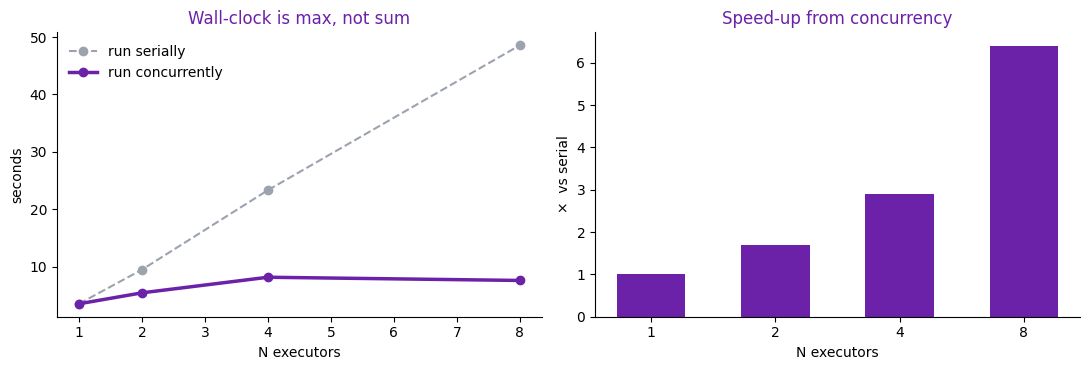

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
PURPLE, GREY = "#6b21a8", "#9ca3af"

ax1.plot(sweep_df["N"], sweep_df["if run serially (s)"], "o--", color=GREY, label="run serially")
ax1.plot(sweep_df["N"], sweep_df["wall-clock (s)"], "o-", color=PURPLE, lw=2.5, label="run concurrently")
ax1.set_xlabel("N executors"); ax1.set_ylabel("seconds")
ax1.set_title("Wall-clock is max, not sum", color=PURPLE)
ax1.legend(frameon=False); ax1.spines[["top", "right"]].set_visible(False)

ax2.bar(sweep_df["N"].astype(str), sweep_df["speed-up"], color=PURPLE, width=0.55)
ax2.set_xlabel("N executors"); ax2.set_ylabel("×  vs serial")
ax2.set_title("Speed-up from concurrency", color=PURPLE)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

---
## 3. Best-of-N — the test suite picks the winner

Concurrency is only interesting if it buys **quality**, not just throughput. Coding agents have a
luxury most agents don't: **ground truth**. The tests pass or they don't.

So: generate N candidate patches, run the real test suite against every one, and keep a winner.
No LLM judge. No rubric. No vibes.

In [12]:
def extract_code(text: str) -> str:
    """Pull the first fenced code block out of a model response."""
    blocks = re.findall(r"```(?:python)?\n(.*?)```", text, re.S)
    return (blocks[0] if blocks else text).strip()


def run_tests(code: str, timeout: int = 120) -> dict:
    """Write the candidate + the suite to an isolated temp dir and actually run pytest.

    This is a real subprocess against real files — the same shape as a sandboxed
    executor, minus the container. Isolation matters: N candidates must never
    share a working tree.
    """
    with tempfile.TemporaryDirectory() as d:
        (Path(d) / "solution.py").write_text(code)
        (Path(d) / "test_solution.py").write_text(TESTS)
        proc = subprocess.run(
            [sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
            cwd=d, capture_output=True, text=True, timeout=timeout,
        )
    out = proc.stdout
    passed = int(m.group(1)) if (m := re.search(r"(\d+) passed", out)) else 0
    failed = int(m.group(1)) if (m := re.search(r"(\d+) failed", out)) else 0
    errors = int(m.group(1)) if (m := re.search(r"(\d+) error", out)) else 0
    return {"ok": proc.returncode == 0, "passed": passed, "failed": failed + errors}

In [13]:
N_CANDIDATES = 12

wall, candidates = await fan_out(N_CANDIDATES)
print(f"Generated {N_CANDIDATES} candidates in {wall:.1f}s wall-clock "
      f"({sum(c['seconds'] for c in candidates):.1f}s if run serially)\n")

scored = []
for c in candidates:
    verdict = run_tests(extract_code(c["text"]))
    scored.append({**c, **verdict})
    print(f"  candidate {c['candidate']:>2}: {c['seconds']:5.1f}s  "
          f"{c['out_tokens']:>5} out-tokens  "
          f"{'PASS' if verdict['ok'] else 'FAIL'}  "
          f"({verdict['passed']} passed / {verdict['failed']} failed)")

n_solved = sum(s["ok"] for s in scored)
print(f"\n{n_solved}/{N_CANDIDATES} candidates passed the full suite.")

Generated 12 candidates in 8.7s wall-clock (80.7s if run serially)



  candidate  0:   4.7s   3324 out-tokens  FAIL  (8 passed / 1 failed)


  candidate  1:   6.3s   2250 out-tokens  PASS  (9 passed / 0 failed)


  candidate  2:   6.3s   2251 out-tokens  FAIL  (7 passed / 2 failed)


  candidate  3:   6.3s   2628 out-tokens  PASS  (9 passed / 0 failed)


...

  candidate  7:   8.6s   2412 out-tokens  PASS  (9 passed / 0 failed)


  candidate  8:   8.6s   2457 out-tokens  PASS  (9 passed / 0 failed)


  candidate  9:   8.7s   2051 out-tokens  FAIL  (7 passed / 2 failed)


  candidate 10:   6.3s   2927 out-tokens  FAIL  (0 passed / 9 failed)


  candidate 11:   6.2s   2566 out-tokens  PASS  (9 passed / 0 failed)

7/12 candidates passed the full suite.


### pass@k — what N actually buys you

`pass@1` is the chance a *single* attempt solves the task. `pass@k` is the chance that **at least
one of k** attempts does. We use the standard unbiased estimator (Chen et al., 2021):

$$\text{pass@}k = 1 - \frac{\binom{n-c}{k}}{\binom{n}{k}}$$

where $n$ is the number of candidates we generated and $c$ is how many of them passed.

In [14]:
def pass_at_k(n: int, c: int, k: int) -> float:
    """Unbiased pass@k estimator: 1 - C(n-c, k)/C(n, k)."""
    if n - c < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)


curve = pd.DataFrame(
    [{"k": k, "pass@k": round(pass_at_k(N_CANDIDATES, n_solved, k), 3)}
     for k in range(1, N_CANDIDATES + 1)]
)

print(f"pass@1  = {curve.loc[0, 'pass@k']:.2f}   (one shot — what a single-executor agent gets)")
print(f"pass@{N_CANDIDATES} = {curve.iloc[-1]['pass@k']:.2f}   (best-of-{N_CANDIDATES}, tests picking the winner)")
curve.T

pass@1  = 0.58   (one shot — what a single-executor agent gets)
pass@12 = 1.00   (best-of-12, tests picking the winner)


,0,1,2,3,4,5,6,7,8,9,10,11
k,1.000,2.000,3.000,4.00,5.000,6.0,7.0,8.0,9.0,10.0,11.0,12.0
pass@k,0.583,0.848,0.955,0.99,0.999,1.0,1.0,1.0,1.0,1.0,1.0,1.0


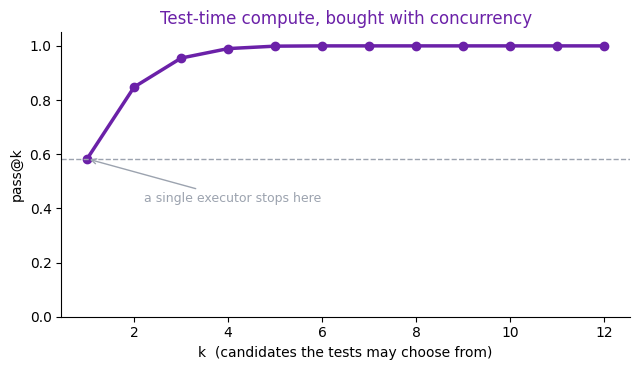

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(curve["k"], curve["pass@k"], "o-", color=PURPLE, lw=2.5)
ax.axhline(curve.loc[0, "pass@k"], ls="--", color=GREY, lw=1)
ax.annotate("a single executor stops here", xy=(1, curve.loc[0, "pass@k"]),
            xytext=(2.2, curve.loc[0, "pass@k"] - 0.16), color=GREY, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=GREY))
ax.set_xlabel("k  (candidates the tests may choose from)")
ax.set_ylabel("pass@k"); ax.set_ylim(0, 1.05)
ax.set_title("Test-time compute, bought with concurrency", color=PURPLE)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

---
## 4. The economics

Concurrency isn't free — you pay N× the executor tokens. The question is whether that is a good
trade, and the answer depends entirely on how cheap the executor is.

```
cost(N)       = plan_cost  +  N × executor_tokens × executor_price
wall-clock(N) = plan_time  +  max(candidate_times)        ← not the sum
```

The tempting claim is that best-of-N lowers your cost per solved task. **It does not** — and it is
worth being precise about why, because the real argument is stronger than the wrong one.

In [16]:
avg_in = sum(c["in_tokens"] for c in candidates) / len(candidates)
avg_out = sum(c["out_tokens"] for c in candidates) / len(candidates)
cost_per_candidate = avg_in * PRICE_IN + avg_out * PRICE_OUT

econ = pd.DataFrame(
    [
        {
            "N": k,
            "pass@k": round(p_k, 3),
            "cost ($)": round(k * cost_per_candidate, 5),
            # Expected cost to actually SOLVE the task: you pay for the attempts,
            # and a run that solves nothing still costs you a retry.
            "cost per solved task ($)": (
                round(k * cost_per_candidate / p_k, 5) if p_k > 0 else float("nan")
            ),
        }
        for k in range(1, N_CANDIDATES + 1)
        if (p_k := pass_at_k(N_CANDIDATES, n_solved, k)) is not None
    ]
)

print(f"Average candidate: {avg_in:,.0f} in + {avg_out:,.0f} out tokens")
print(f"Cost per candidate: ${cost_per_candidate:.5f}")
print(f"Best-of-{N_CANDIDATES} costs ${N_CANDIDATES * cost_per_candidate:.4f} — "
      f"about {N_CANDIDATES * cost_per_candidate * 100:.2f} cents.\n")
econ

Average candidate: 387 in + 2,581 out tokens
Cost per candidate: $0.00161
Best-of-12 costs $0.0193 — about 1.93 cents.



,N,pass@k,cost ($),cost per solved task ($)
0,1,0.583,0.00161,0.00276
1,2,0.848,0.00322,0.00379
2,3,0.955,0.00482,0.00505
3,4,0.990,0.00643,0.00650
4,5,0.999,0.00804,0.00805
5,6,1.000,0.00965,0.00965
6,7,1.000,0.01125,0.01125
7,8,1.000,0.01286,0.01286
8,9,1.000,0.01447,0.01447
9,10,1.000,0.01608,0.01608


Look at the last column: it is **lowest at N = 1**, and it rises from there. That is not an
accident of this run — it is arithmetic. Since $\text{pass@}k \le k \cdot \text{pass@}1$, cost
grows linearly in N while pass@k saturates, so cost-per-solved is *always* minimised at N = 1.

**So what does best-of-N actually buy?** Not cheaper tokens — **reliability, at a latency you can
afford**. A single attempt is a coin-flip you cannot detect without running the tests anyway; N
attempts turn a ~50% executor into a ~100% one, in roughly the same wall-clock.

Which reframes the real comparison. It is not "N attempts vs 1 attempt on the same model". It is:

> **a cheap, fast executor run N times** &nbsp;vs&nbsp; **an expensive model run once**

Let's price that honestly, with a real run.

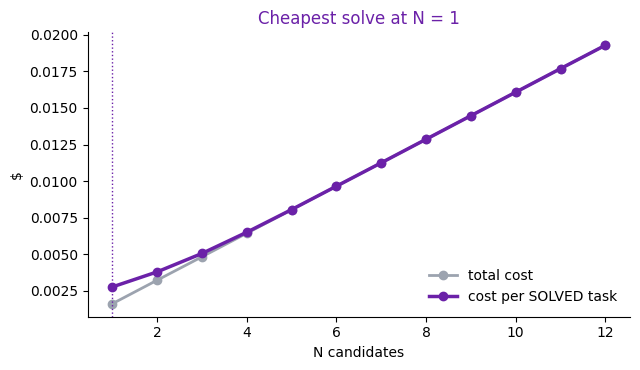

Cheapest cost per solved task: $0.00276 at N=1


In [17]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(econ["N"], econ["cost ($)"], "o-", color=GREY, lw=2, label="total cost")
ax.plot(econ["N"], econ["cost per solved task ($)"], "o-", color=PURPLE, lw=2.5,
        label="cost per SOLVED task")
solved_col = econ["cost per solved task ($)"]
if solved_col.notna().any():
    best = econ.loc[solved_col.idxmin()]
    ax.axvline(best["N"], ls=":", color=PURPLE, lw=1)
    ax.set_title(f"Cheapest solve at N = {int(best['N'])}", color=PURPLE)
else:
    best = None
    ax.set_title("No candidate solved the task this run", color=PURPLE)
ax.set_xlabel("N candidates"); ax.set_ylabel("$")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

if best is not None:
    print(f"Cheapest cost per solved task: ${best['cost per solved task ($)']:.5f} at N={int(best['N'])}")
else:
    print("Zero candidates passed this run — rerun the fan-out, or raise N_CANDIDATES.")
    print("This is worth seeing: pass@1 is a *distribution*, not a constant.")

In [18]:
# What does best-of-N cost in the only currency that matters here — engineer time?
DEV_HOURLY = 90.0          # fully-loaded cost of an engineer, $/hour
dev_minute = DEV_HOURLY / 60

best_of_n_cost = N_CANDIDATES * cost_per_candidate
minutes_of_dev_time = best_of_n_cost / dev_minute

print(f"Best-of-{N_CANDIDATES} on this task:  ${best_of_n_cost:.4f}")
print(f"That is {minutes_of_dev_time*60:.1f} SECONDS of one engineer's time.")
print()
print(f"pass@1  = {pass_at_k(N_CANDIDATES, n_solved, 1):.2f}  -> roughly "
      f"{(1-pass_at_k(N_CANDIDATES, n_solved, 1))*100:.0f}% of single attempts need a human retry")
print(f"pass@{N_CANDIDATES} = {pass_at_k(N_CANDIDATES, n_solved, N_CANDIDATES):.2f}")

Best-of-12 on this task:  $0.0193
That is 0.8 SECONDS of one engineer's time.

pass@1  = 0.58  -> roughly 42% of single attempts need a human retry
pass@12 = 1.00


That is the real economic argument, and it does not need a competitor to land:

* Best-of-N costs **cents**, not dollars — a rounding error against a single engineer-minute.
* A failed single attempt is **not** free: it costs a retry, a context switch, or a human.
* The binding constraint was never the money — it was the **wall-clock**. Best-of-N is only a
  real option because N candidates finish in about the time one does.

*(One task, one small sample — treat the shape as the lesson, not the exact digits.
Session 4 builds the eval harness that makes this rigorous.)*

---
## 5. From a notebook to a platform

Everything above ran in one process on one machine. Three things change the moment you serve
this for a team — and they are the difference between a demo and a product.

### Sandboxes
Isolation is a **correctness** requirement before it is a security one: N agents editing one
working tree is a race condition. Above, `run_tests()` used a fresh `TemporaryDirectory` per
candidate for exactly this reason. In production that becomes a container per run, and then:

* **Key the sandbox by _session_, not run**, so a follow-up turn reuses the warm container —
  clone and dependency bootstrap are usually the largest fixed cost per turn.
* **Warm vs cold resume.** Durable state lives in your database, the agent's pushed git branch,
  and a snapshot of the harness's own session files — so a reaped container *resumes* rather
  than restarts.
* **Three separate caps, three separate failure modes:** a global in-flight pool, a per-user
  container cap, and a per-agent concurrency limit.
* **Secrets, when the code is model-written.** Don't harden the sandbox *around* the key — keep
  the key **out** of the sandbox. Route model and git traffic through short-lived per-run proxy
  tokens, inject real credentials server-side, and put egress on a deny-by-default allowlist.
  A prompt-injected agent then has nothing to exfiltrate.

### Processes
`asyncio.gather` is a fine fan-out primitive for one notebook. A fleet needs a dispatcher:

* a claim-loop that tops an in-flight pool up to a cap and runs each task fire-and-forget;
* per-run hard timeouts, retries with backoff, and **orphan recovery** on restart — reset the
  runs a dead process left marked `running`;
* tear the sandbox down in a `finally` (leaked containers are the classic slow death);
* persist logs **per chunk**, so a run killed by its timeout still leaves the evidence you need.

### Context
Every parallel executor pays its own context bill, so concurrency **multiplies** context cost and
per-request context becomes the lever. Drive compaction from **real model metadata** — the
`COMPACT_AT` we computed in §0 from the live registry, not a hard-coded constant — and use
progressive disclosure (load a skill's name and description; read its body only when selected)
to keep each request small.

---
## Takeaways

1. **Interactivity is an engineering spec.** An agent's wall-clock is tokens ÷ throughput across
   dozens of turns — we measured it, then watched the same agent become unusable purely by
   changing how fast it was served.
2. **Concurrency turns a sum into a max.** N attempts cost N× the tokens but roughly 1× the time.
3. **Tests are the selector.** Coding agents have ground truth, so best-of-N needs no judge —
   and pass@k climbs steeply from a mediocre pass@1.
4. **Best-of-N does not buy cheaper tokens — it buys reliability at an affordable latency.**
   The honest comparison is a cheap executor run N times against an expensive model run once.
5. **Serving many agents well is a different problem from serving one agent fast.** Sandboxes,
   dispatcher processes, and per-request context are what stand between this notebook and a
   platform.

### Next session
**Session 3 — Giving the Agent an Environment: Tools, Tests, Git, and MCP.** We give the executor
a real workspace and let it open a PR-style diff that passes CI.